In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud

# --- NEW IMPORTS FOR PREPROCESSING ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (uncomment these if you get missing package errors)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('wordnet')

# 1. Load the Dataset
train_dataset = load_dataset('parquet', data_files={'train': os.path.join('..', 'data', 'train-00000-of-00001.parquet')})
train_df = train_dataset['train'].to_pandas()

# 2. Define the Preprocess Function
def preprocess(sentences):
    base_stop_words = set(stopwords.words('english'))
    words_to_keep = {'what', 'where', 'who', 'why', 'how', 'when', 'do'}
    custom_stop_words = base_stop_words - words_to_keep
    allowed_symbols = {'?', '!'}
    
    lemmatizer = WordNetLemmatizer()
    result = []
    
    for sent in sentences:
        tokens = word_tokenize(sent)
        pos_tags = nltk.pos_tag(tokens)
        cleaned = []
        for token, pos in pos_tags:
            t = token.lower()
            if (t not in custom_stop_words) and (t.isalpha() or t in allowed_symbols):
                if t.isalpha():
                    if pos.startswith('NN'):   lemma = lemmatizer.lemmatize(t, 'n')
                    elif pos.startswith('VB'): lemma = lemmatizer.lemmatize(t, 'v')
                    elif pos.startswith('JJ'): lemma = lemmatizer.lemmatize(t, 'a')
                    else:                      lemma = lemmatizer.lemmatize(t)
                else:
                    lemma = t
                cleaned.append(lemma)
        result.append(' '.join(cleaned))
    return result

# 3. Apply Preprocessing to the Data
print("Preprocessing text... this might take a minute depending on your CPU.")
train_df['clean_text'] = preprocess(train_df['text'].tolist())
print("Preprocessing complete!")

# 4. Add word count features for both raw and cleaned text
train_df['word_count_raw'] = train_df['text'].apply(lambda x: len(str(x).split()))
train_df['word_count_clean'] = train_df['clean_text'].apply(lambda x: len(str(x).split()))

Preprocessing text... this might take a minute depending on your CPU.
Preprocessing complete!


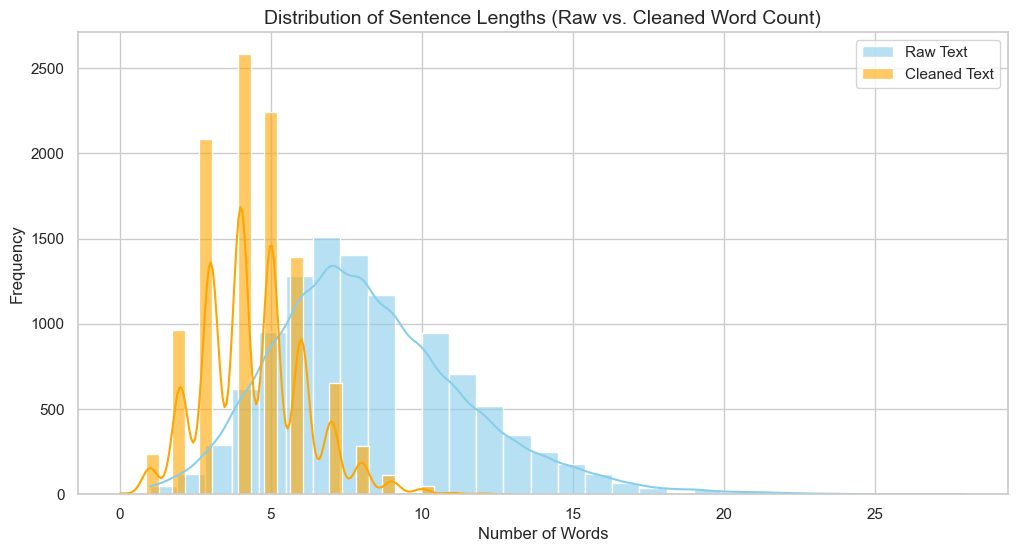

In [3]:
# Set the style for seaborn
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Visualization 1: Distribution of Text Lengths (Raw vs Clean)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot raw text length in blue
sns.histplot(train_df['word_count_raw'], bins=30, kde=True, color='skyblue', label='Raw Text', alpha=0.6)

# Plot clean text length in orange
sns.histplot(train_df['word_count_clean'], bins=30, kde=True, color='orange', label='Cleaned Text', alpha=0.6)

plt.title('Distribution of Sentence Lengths (Raw vs. Cleaned Word Count)', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

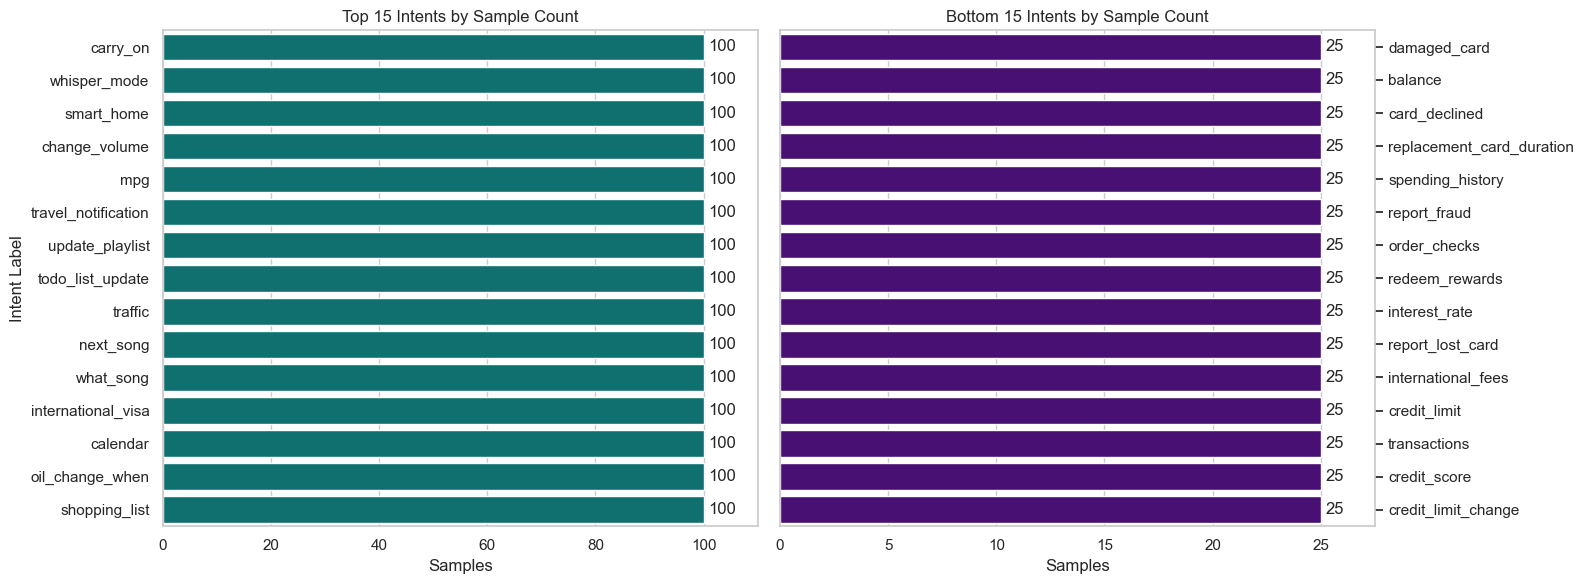

In [10]:
# ---------------------------------------------------------
# Visualization 2: Class Balance (Top & Bottom 15 Intents)
# ---------------------------------------------------------
# FIXED: We use 'intent' here, because class balance doesn't change after text cleaning!
intent_counts = train_df['intent'].value_counts()

intent_mapping = {
    0: 'restaurant_reviews', 1: 'nutrition_info', 2: 'account_blocked', 3: 'oil_change_how', 4: 'time', 
    5: 'weather', 6: 'redeem_rewards', 7: 'interest_rate', 8: 'gas_type', 9: 'accept_reservations', 
    10: 'smart_home', 11: 'user_name', 12: 'report_lost_card', 13: 'repeat', 14: 'whisper_mode', 
    15: 'what_are_your_hobbies', 16: 'order', 17: 'jump_start', 18: 'schedule_meeting', 19: 'meeting_schedule', 
    20: 'freeze_account', 21: 'what_song', 22: 'meaning_of_life', 23: 'restaurant_reservation', 24: 'traffic', 
    25: 'make_call', 26: 'text', 27: 'bill_balance', 28: 'improve_credit_score', 29: 'change_language', 
    30: 'no', 31: 'measurement_conversion', 32: 'timer', 33: 'flip_coin', 34: 'do_you_have_pets', 
    35: 'balance', 36: 'tell_joke', 37: 'last_maintenance', 38: 'exchange_rate', 39: 'uber', 
    40: 'car_rental', 41: 'credit_limit', 42: 'oos', 43: 'shopping_list', 44: 'expiration_date', 
    45: 'routing', 46: 'meal_suggestion', 47: 'tire_change', 48: 'todo_list', 49: 'card_declined', 
    50: 'rewards_balance', 51: 'change_accent', 52: 'vaccines', 53: 'reminder_update', 54: 'food_last', 
    55: 'change_ai_name', 56: 'bill_due', 57: 'who_do_you_work_for', 58: 'share_location', 59: 'international_visa', 
    60: 'calendar', 61: 'translate', 62: 'carry_on', 63: 'book_flight', 64: 'insurance_change', 
    65: 'todo_list_update', 66: 'timezone', 67: 'cancel_reservation', 68: 'transactions', 69: 'credit_score', 
    70: 'report_fraud', 71: 'spending_history', 72: 'directions', 73: 'spelling', 74: 'insurance', 
    75: 'what_is_your_name', 76: 'reminder', 77: 'where_are_you_from', 78: 'distance', 79: 'payday', 
    80: 'flight_status', 81: 'find_phone', 82: 'greeting', 83: 'alarm', 84: 'order_status', 
    85: 'confirm_reservation', 86: 'cook_time', 87: 'damaged_card', 88: 'reset_settings', 89: 'pin_change', 
    90: 'replacement_card_duration', 91: 'new_card', 92: 'roll_dice', 93: 'income', 94: 'taxes', 
    95: 'date', 96: 'who_made_you', 97: 'pto_request', 98: 'tire_pressure', 99: 'how_old_are_you', 
    100: 'rollover_401k', 101: 'pto_request_status', 102: 'how_busy', 103: 'application_status', 104: 'recipe', 
    105: 'calendar_update', 106: 'play_music', 107: 'yes', 108: 'direct_deposit', 109: 'credit_limit_change', 
    110: 'gas', 111: 'pay_bill', 112: 'ingredients_list', 113: 'lost_luggage', 114: 'goodbye', 
    115: 'what_can_i_ask_you', 116: 'book_hotel', 117: 'are_you_a_bot', 118: 'next_song', 119: 'change_speed', 
    120: 'plug_type', 121: 'maybe', 122: 'w2', 123: 'oil_change_when', 124: 'thank_you', 125: 'shopping_list_update', 
    126: 'pto_balance', 127: 'order_checks', 128: 'travel_alert', 129: 'fun_fact', 130: 'sync_device', 
    131: 'schedule_maintenance', 132: 'apr', 133: 'transfer', 134: 'ingredient_substitution', 135: 'calories', 
    136: 'current_location', 137: 'international_fees', 138: 'calculator', 139: 'definition', 140: 'next_holiday', 
    141: 'update_playlist', 142: 'mpg', 143: 'min_payment', 144: 'change_user_name', 145: 'restaurant_suggestion', 
    146: 'travel_notification', 147: 'cancel', 148: 'pto_used', 149: 'travel_suggestion', 150: 'change_volume'
}

# 1. Map the numeric IDs to their text labels
top_15_labels = [intent_mapping.get(int(idx), str(idx)) for idx in intent_counts.head(15).index]
bottom_15_labels = [intent_mapping.get(int(idx), str(idx)) for idx in intent_counts.tail(15).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Top 15 Intents 
sns.barplot(y=top_15_labels, x=intent_counts.head(15).values, ax=axes[0], color='teal')
axes[0].set_title('Top 15 Intents by Sample Count')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Intent Label')
axes[0].bar_label(axes[0].containers[0], padding=3)

# 3. Bottom 15 Intents 
sns.barplot(y=bottom_15_labels, x=intent_counts.tail(15).values, ax=axes[1], color='indigo')
axes[1].set_title('Bottom 15 Intents by Sample Count')
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('')
axes[1].bar_label(axes[1].containers[0], padding=3)

# Move the labels to the right side of the second plot as requested
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")

axes[0].margins(x=0.1)
axes[1].margins(x=0.1)

plt.tight_layout()
plt.show()

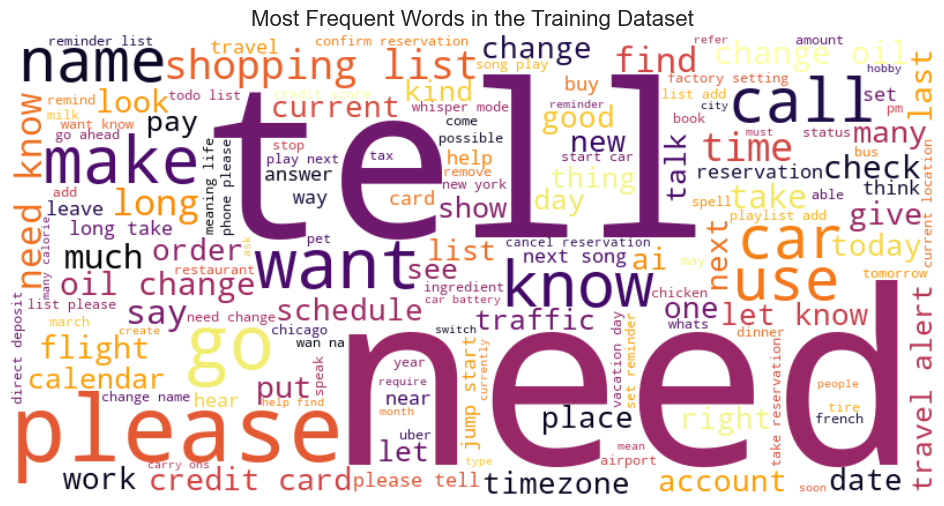

In [13]:
# ---------------------------------------------------------
# Visualization 3: Word Cloud of the CLEANED Corpus
# ---------------------------------------------------------
# FIXED: We use 'clean_text' here, not 'word_count_clean'
all_clean_text = " ".join(train_df['clean_text'].dropna().tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='inferno', max_words=150).generate(all_clean_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Frequent Words in the Training Dataset', fontsize=16)
plt.axis('off')
plt.show()